# Task 4: Sales Dataset (Superstore) - Data Cleaning & Basic EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Cleaning

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop_duplicates(inplace=True)
df.drop(['Row ID'], axis=1, inplace=True)

In [7]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_683/1004626334.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Category'] = df['Category'].astype('category')
df['Sub-Category'] = df['Sub-Category'].astype('category')
df['Region'] = df['Region'].astype('category')
df['Segment'] = df['Segment'].astype('category')

In [9]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

df = remove_outliers_iqr(df, 'Sales')
df = remove_outliers_iqr(df, 'Profit')
df.reset_index(drop=True, inplace=True)

In [10]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

## Summary Statistics

In [11]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,7392.000000,7392.000000,7392.000000,7392.000000
mean,62.314599,3.464962,0.148635,9.636050
std,82.271335,2.041211,0.199668,13.843595
min,0.444000,1.000000,0.000000,-27.735000
25%,12.960000,2.000000,0.000000,2.133200
50%,30.560000,3.000000,0.200000,6.797800
75%,75.850000,5.000000,0.200000,16.016250
max,496.860000,14.000000,0.800000,50.584800


In [12]:
df.groupby('Category')[['Sales', 'Profit']].agg(['sum', 'mean', 'count'])

Sales                        Profit                 
                         sum        mean count         sum       mean count
Category                                                                   
Furniture        138527.9269  110.822342  1250  11463.2343   9.170587  1250
Office Supplies  202364.2100   40.072121  5050  44257.0537   8.763773  5050
Technology       119737.3790  109.649614  1092  15509.3965  14.202744  1092

In [13]:
df.groupby('Region')[['Sales', 'Profit']].agg(['sum', 'mean', 'count'])

Sales                       Profit                 
                 sum       mean count         sum       mean count
Region                                                            
Central   95091.4404  57.180662  1663  11216.9376   6.745002  1663
East     116104.7900  55.873335  2078  19503.6842   9.385796  2078
South     72680.4480  60.718837  1197  11529.6173   9.632095  1197
West     176752.8375  72.026421  2454  28979.4454  11.809065  2454

In [14]:
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

Sub-Category
Phones         70392.7120
Storage        64172.8700
Chairs         57976.0480
Accessories    46412.6440
Furnishings    45243.0300
Paper          38317.4380
Binders        30063.8590
Appliances     22485.3650
Art            21633.1280
Bookcases      21301.8579
Tables         14006.9910
Supplies        7728.7720
Labels          7561.0640
Envelopes       7377.4340
Fasteners       3024.2800
Machines        2932.0230
Name: Sales, dtype: float64

## Exploratory Data Analysis

/tmp/ipykernel_683/724383655.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Category', y='Sales', estimator=sum, ci=None)


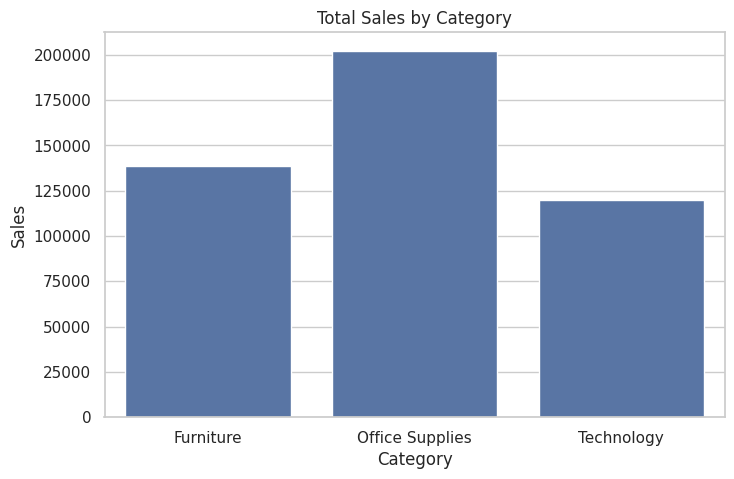

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Category', y='Sales', estimator=sum, ci=None)
plt.title('Total Sales by Category')
plt.show()

/tmp/ipykernel_683/3876441153.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Sub-Category', y='Sales', estimator=sum, ci=None)


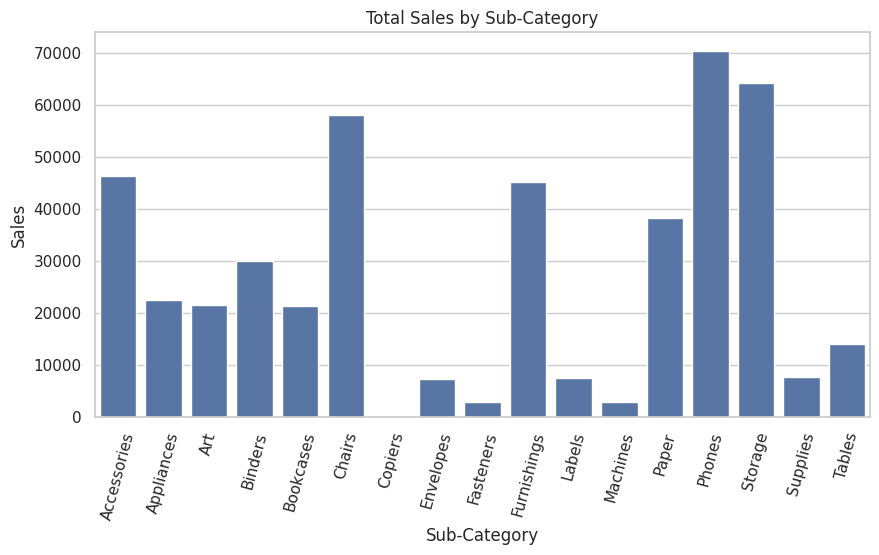

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Sub-Category', y='Sales', estimator=sum, ci=None)
plt.title('Total Sales by Sub-Category')
plt.xticks(rotation=75)
plt.show()

/tmp/ipykernel_683/1576225628.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Region', y='Sales', estimator=sum, ci=None)


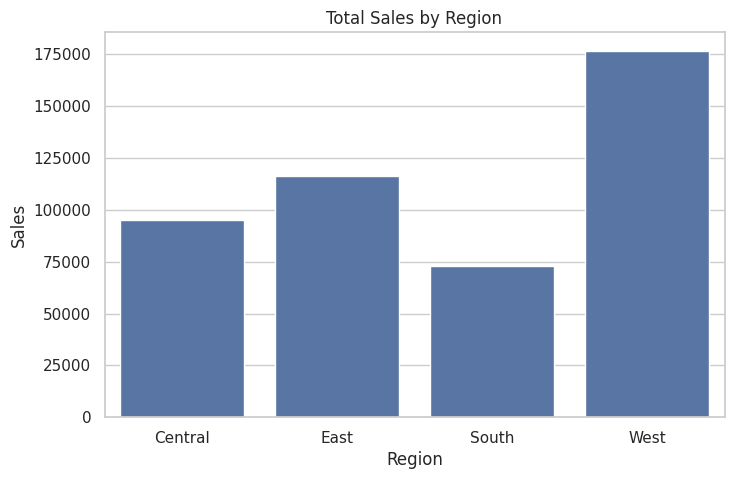

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Region', y='Sales', estimator=sum, ci=None)
plt.title('Total Sales by Region')
plt.show()

/tmp/ipykernel_683/2736453280.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Segment', y='Sales', estimator=sum, ci=None)


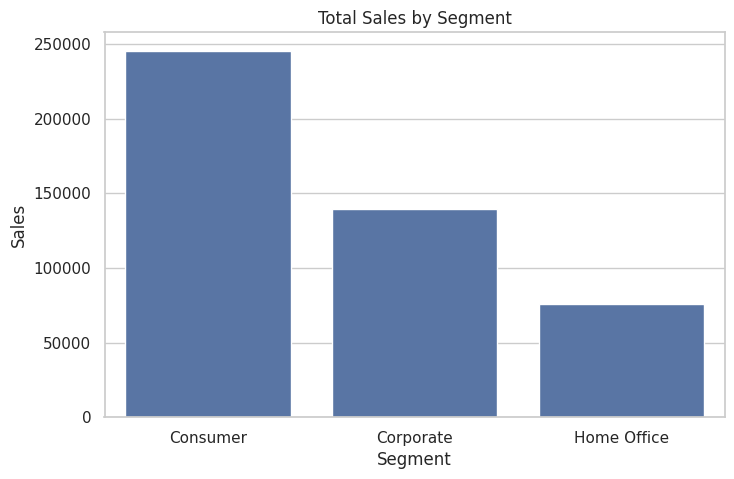

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Segment', y='Sales', estimator=sum, ci=None)
plt.title('Total Sales by Segment')
plt.show()

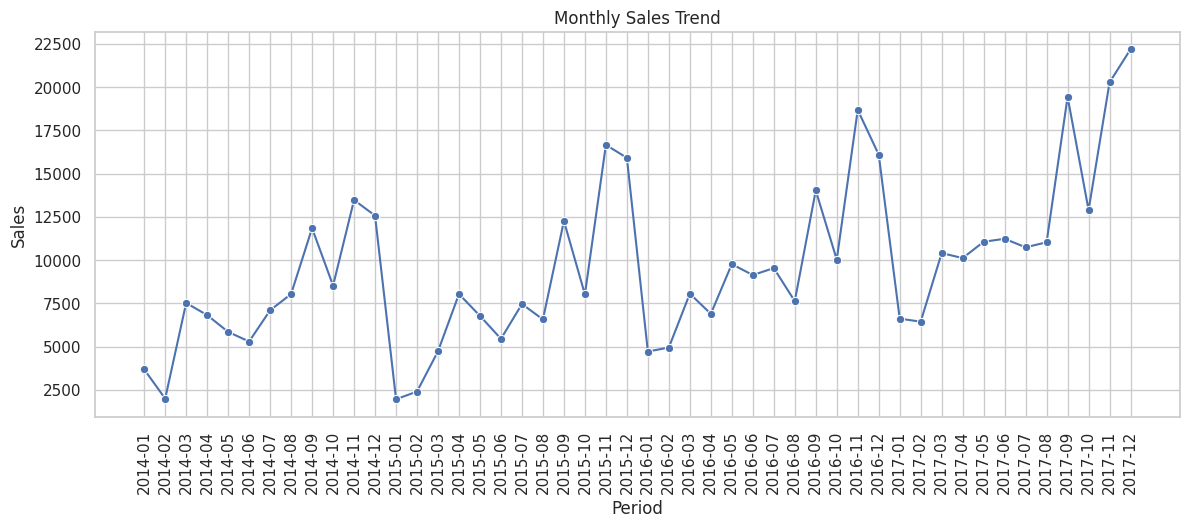

In [19]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['Period'] = monthly_sales['Order Year'].astype(str) + '-' + monthly_sales['Order Month'].astype(str).str.zfill(2)

plt.figure(figsize=(14,5))
sns.lineplot(data=monthly_sales, x='Period', y='Sales', marker='o')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=90)
plt.show()

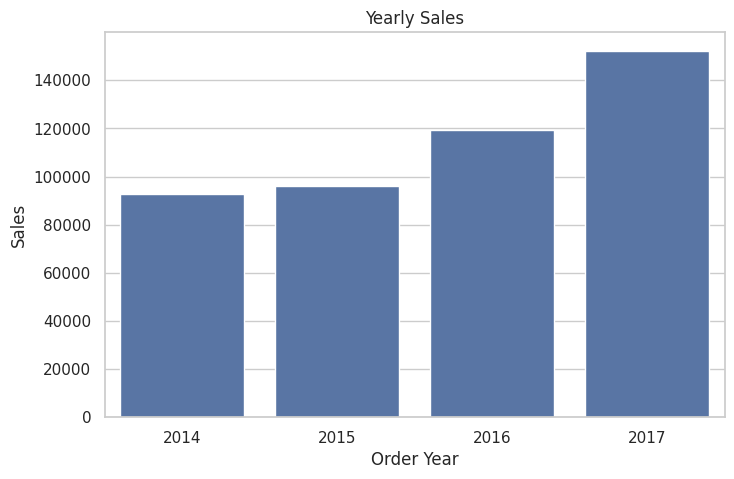

In [20]:
yearly_sales = df.groupby('Order Year')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=yearly_sales, x='Order Year', y='Sales')
plt.title('Yearly Sales')
plt.show()

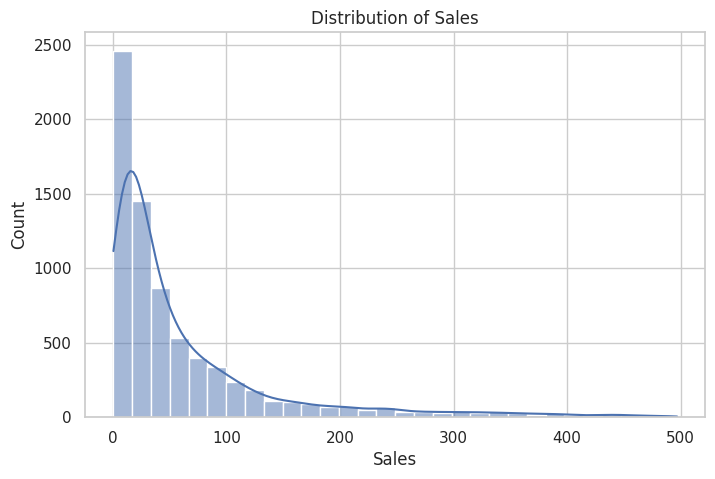

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Distribution of Sales')
plt.show()

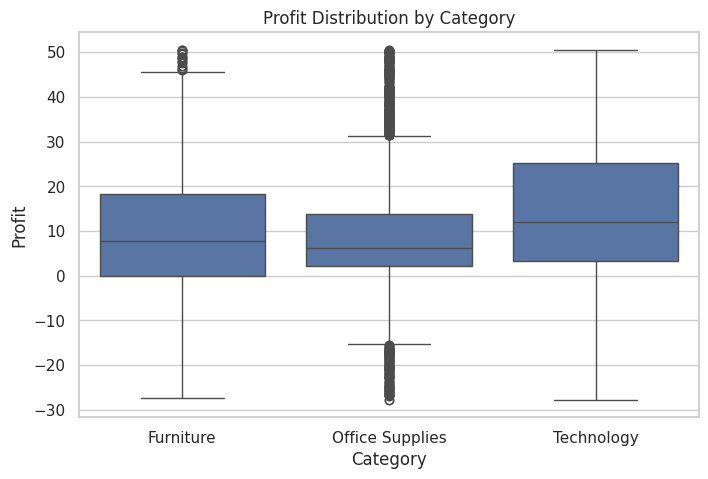

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Category', y='Profit')
plt.title('Profit Distribution by Category')
plt.show()

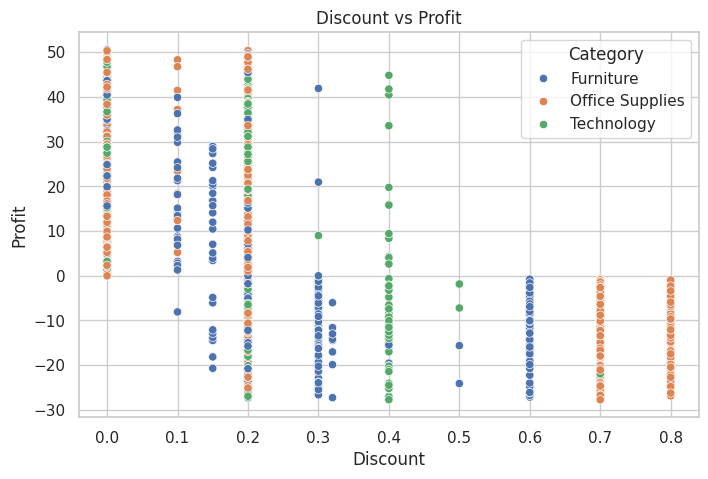

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
plt.title('Discount vs Profit')
plt.show()

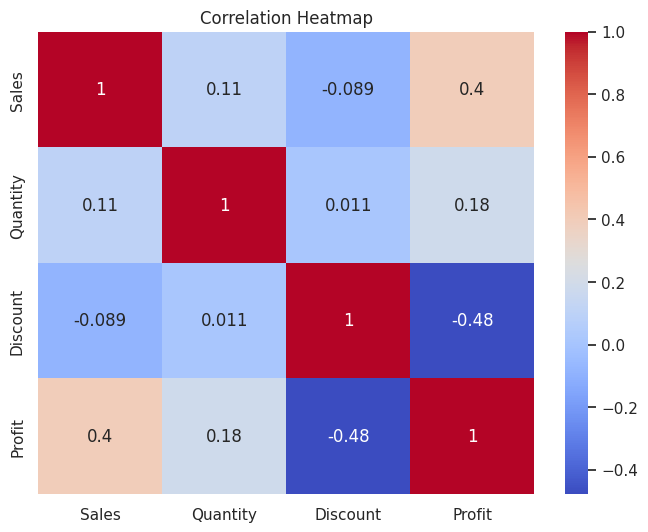

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Quantity','Discount','Profit']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

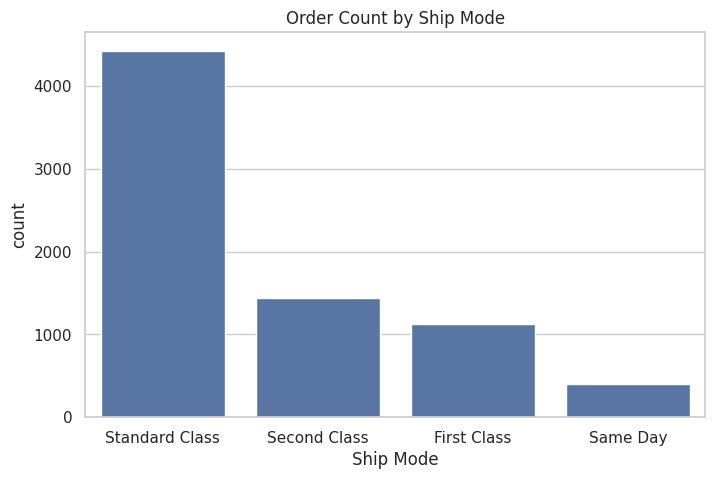

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Ship Mode', order=df['Ship Mode'].value_counts().index)
plt.title('Order Count by Ship Mode')
plt.show()

## Key Insights

In [26]:
top_category = df.groupby('Category')['Sales'].sum().idxmax()
top_subcategory = df.groupby('Sub-Category')['Sales'].sum().idxmax()
top_region = df.groupby('Region')['Sales'].sum().idxmax()
best_year = df.groupby('Order Year')['Sales'].sum().idxmax()
most_profitable_category = df.groupby('Category')['Profit'].sum().idxmax()
least_profitable_subcategory = df.groupby('Sub-Category')['Profit'].sum().idxmin()

print("Top Selling Category:", top_category)
print("Top Selling Sub-Category:", top_subcategory)
print("Top Selling Region:", top_region)
print("Best Sales Year:", best_year)
print("Most Profitable Category:", most_profitable_category)
print("Least Profitable Sub-Category:", least_profitable_subcategory)

Top Selling Category: Office Supplies
Top Selling Sub-Category: Phones
Top Selling Region: West
Best Sales Year: 2017
Most Profitable Category: Office Supplies
Least Profitable Sub-Category: Tables
